Example 1

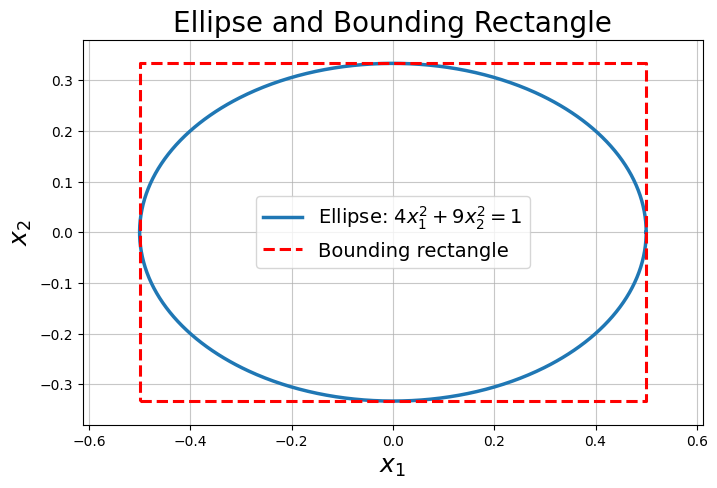

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

# ==================================================
# Matrix A = diag(4,9)
# Ellipse: x^T A x = 1
# ==================================================

a11 = 4
a22 = 9

# Semi-axes of the ellipse
a = 1 / np.sqrt(a11)   # x1 semi-axis
b = 1 / np.sqrt(a22)   # x2 semi-axis

# Parametric representation
t = np.linspace(0, 2*np.pi, 1000)
x1 = a * np.cos(t)
x2 = b * np.sin(t)

# Rectangle vertices
rect_x = [-a, a, a, -a, -a]
rect_y = [-b, -b, b, b, -b]

# ==================================================
# Plot
# ==================================================

plt.figure(figsize=(8, 5))

# Ellipse
plt.plot(
    x1, x2,
    linewidth=2.5,
    label=r'Ellipse: $4x_1^2 + 9x_2^2 = 1$'
)

# Bounding rectangle
plt.plot(
    rect_x, rect_y,
    'r--',
    linewidth=2.2,
    label='Bounding rectangle'
)

plt.title('Ellipse and Bounding Rectangle', fontsize=20)
plt.xlabel(r'$x_1$', fontsize=18)
plt.ylabel(r'$x_2$', fontsize=18)

plt.grid(True, alpha=0.7)

plt.axis('equal')

plt.xlim(-0.55, 0.55)
plt.ylim(-0.38, 0.38)

plt.legend(fontsize=14)

# Save figure
filename = 'ellipse_bounding_rectangle.png'
plt.savefig(filename, dpi=300, bbox_inches='tight')

plt.show()

# Download to computer
#files.download(filename)

Example 2

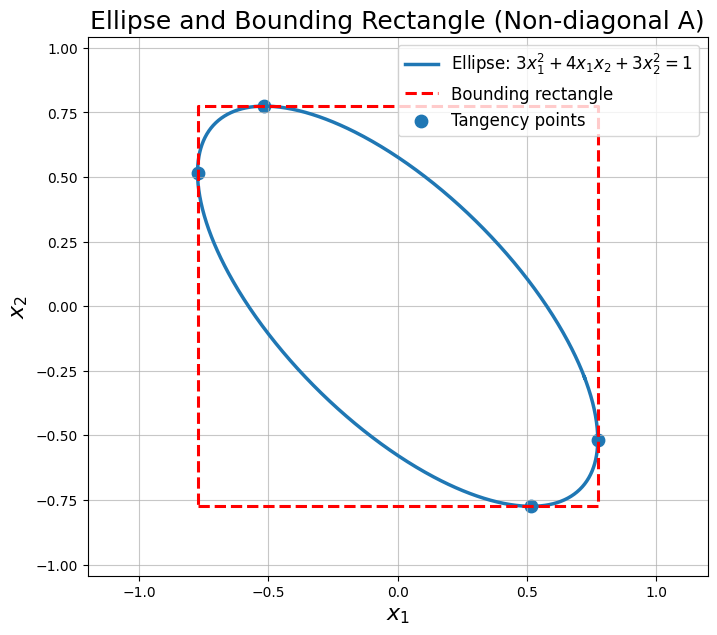

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

# ============================================================
# Matrix A
# ============================================================

A = np.array([[3, 2],
              [2, 3]])

# ============================================================
# Ellipse x^T A x = 1
# Parametrization using A^{-1/2}
# ============================================================

eigvals, eigvecs = np.linalg.eigh(A)

A_inv_sqrt = eigvecs @ np.diag(1/np.sqrt(eigvals)) @ eigvecs.T

theta = np.linspace(0, 2*np.pi, 1000)

circle = np.vstack((np.cos(theta), np.sin(theta)))
ellipse = A_inv_sqrt @ circle

x = ellipse[0, :]
y = ellipse[1, :]

# ============================================================
# Tangency points
# ============================================================

sqrt35 = np.sqrt(3/5)
sqrt415 = np.sqrt(4/15)

P1 = np.array([-(2/3)*sqrt35,  sqrt35])
P2 = np.array([(2/3)*sqrt35,  -sqrt35])

P3 = np.array([-(3/2)*sqrt415,  np.sqrt(4/15)])
P4 = np.array([(3/2)*sqrt415,  -np.sqrt(4/15)])

tangency_points = np.array([P1, P2, P3, P4])

# ============================================================
# Bounding rectangle
# ============================================================

xmax = (3/2)*np.sqrt(4/15)
ymax = np.sqrt(3/5)

rect_x = [-xmax, xmax, xmax, -xmax, -xmax]
rect_y = [-ymax, -ymax, ymax, ymax, -ymax]

# ============================================================
# Plot
# ============================================================

plt.figure(figsize=(8, 7))

# Ellipse
plt.plot(
    x, y,
    linewidth=2.5,
    label=r'Ellipse: $3x_1^2+4x_1x_2+3x_2^2=1$'
)

# Rectangle
plt.plot(
    rect_x,
    rect_y,
    'r--',
    linewidth=2.2,
    label='Bounding rectangle'
)

# Tangency points
plt.scatter(
    tangency_points[:,0],
    tangency_points[:,1],
    s=80,
    label='Tangency points'
)

plt.title('Ellipse and Bounding Rectangle (Non-diagonal A)', fontsize=18)

plt.xlabel(r'$x_1$', fontsize=16)
plt.ylabel(r'$x_2$', fontsize=16)

plt.grid(True, alpha=0.7)

plt.axis('equal')

plt.xlim(-1.2, 1.2)
plt.ylim(-1.2, 1.2)

plt.legend(fontsize=12)

# ============================================================
# Save and download
# ============================================================

filename = 'ellipse_non_diagonal_bounding_rectangle.png'

plt.savefig(
    filename,
    dpi=300,
    bbox_inches='tight'
)

plt.show()

#files.download(filename)

Example 3

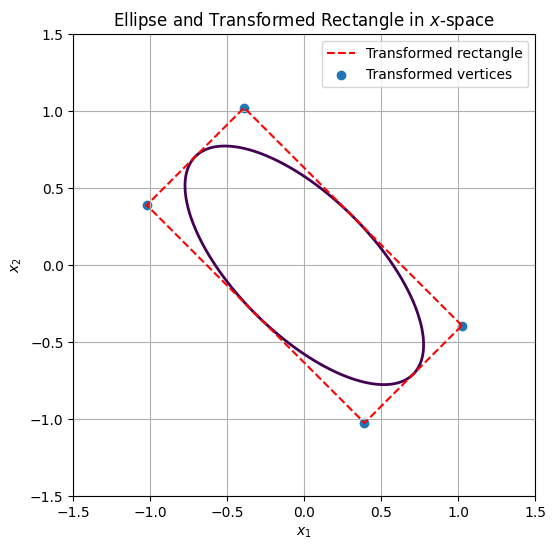

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

# Matrix A
A = np.array([[3,2],
              [2,3]])

# Orthogonal matrix Q
Q = (1/np.sqrt(2)) * np.array([[1,1],
                               [1,-1]])

# Rectangle in y-space
y1_vals = [1/np.sqrt(5), 1/np.sqrt(5), -1/np.sqrt(5), -1/np.sqrt(5)]
y2_vals = [1, -1, 1, -1]

# Vertices in y (ordered to form rectangle)
Y_vertices = np.array([
    [ 1/np.sqrt(5),  1],
    [ 1/np.sqrt(5), -1],
    [-1/np.sqrt(5), -1],
    [-1/np.sqrt(5),  1],
    [ 1/np.sqrt(5),  1]  # close the polygon
])

# Transform vertices to x-space: x = Qy
X_vertices = (Q @ Y_vertices.T).T

# Create grid for ellipse
x = np.linspace(-1.5,1.5,400)
y = np.linspace(-1.5,1.5,400)
X, Y = np.meshgrid(x,y)

# Ellipse equation x^T A x = 1
Z = A[0,0]*X**2 + 2*A[0,1]*X*Y + A[1,1]*Y**2

# Plot
plt.figure(figsize=(6,6))

# Ellipse
plt.contour(X, Y, Z, levels=[1], linewidths=2)

# Transformed rectangle
plt.plot(X_vertices[:,0], X_vertices[:,1], 'r--', label="Transformed rectangle")

# Plot vertices
plt.scatter(X_vertices[:-1,0], X_vertices[:-1,1], label="Transformed vertices")

# Labels
plt.xlabel("$x_1$")
plt.ylabel("$x_2$")
plt.title("Ellipse and Transformed Rectangle in $x$-space")
plt.legend()
plt.grid(True)
plt.gca().set_aspect('equal')

# Save figure
filename = "transformed_rectangle_x_space.png"
plt.savefig(filename, dpi=300, bbox_inches='tight')

plt.show()

# Download
files.download(filename)

Example 4

Matrix A:
[[3 2]
 [2 3]]

Eigenvalues:
[1. 5.]

Eigenvectors:
[[-0.70710678  0.70710678]
 [ 0.70710678  0.70710678]]


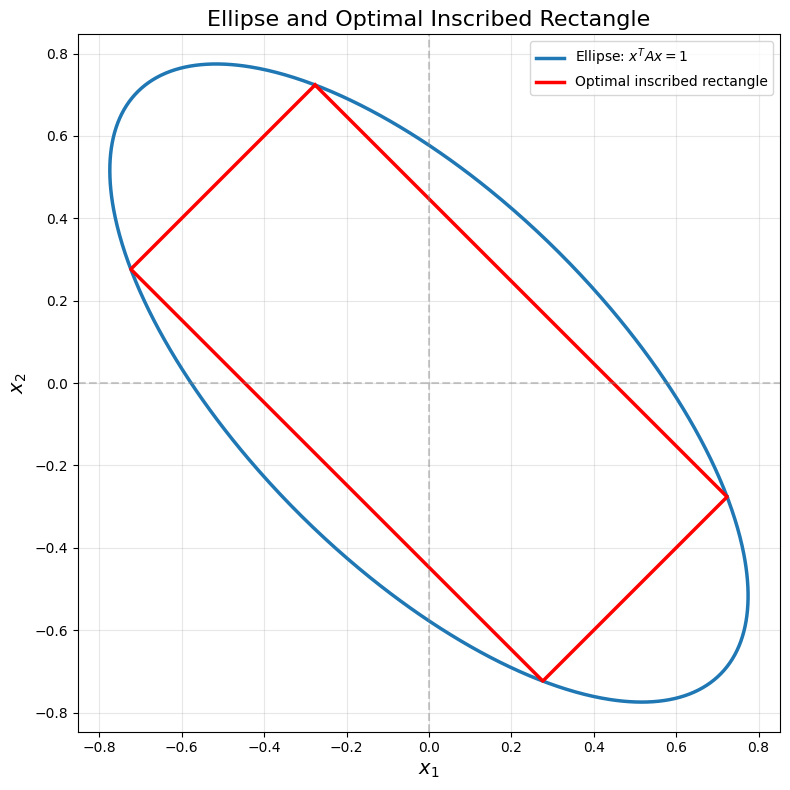


Verification x^T A x = 1

Vertex 1: [-0.2763932  0.7236068] --> x^T A x = 1.0000000000
Vertex 2: [-0.7236068  0.2763932] --> x^T A x = 1.0000000000
Vertex 3: [ 0.2763932 -0.7236068] --> x^T A x = 1.0000000000
Vertex 4: [ 0.7236068 -0.2763932] --> x^T A x = 1.0000000000


In [6]:
import numpy as np
import matplotlib.pyplot as plt

# ==================================================
# Matrix
# ==================================================

A = np.array([[3, 2], [2, 3]])

# ==================================================
# Spectral decomposition
# ==================================================

eigvals, Q = np.linalg.eigh(A)

print("Matrix A:")
print(A)

print("\nEigenvalues:")
print(eigvals)

print("\nEigenvectors:")
print(Q)

# ==================================================
# Ellipse x^T A x = 1
# ==================================================

theta = np.linspace(0, 2*np.pi, 1000)

circle = np.vstack([
    np.cos(theta),
    np.sin(theta)
])

A_inv_sqrt = Q @ np.diag(1/np.sqrt(eigvals)) @ Q.T
ellipse = A_inv_sqrt @ circle

# ==================================================
# Optimal inscribed rectangle
# ==================================================

y_vertices = np.array([
    [ 1/np.sqrt(2*eigvals[0]),  1/np.sqrt(2*eigvals[1])],
    [ 1/np.sqrt(2*eigvals[0]), -1/np.sqrt(2*eigvals[1])],
    [-1/np.sqrt(2*eigvals[0]), -1/np.sqrt(2*eigvals[1])],
    [-1/np.sqrt(2*eigvals[0]),  1/np.sqrt(2*eigvals[1])]
])

vertices = (Q @ y_vertices.T).T
rect_vertices = np.vstack([vertices, vertices[0]])

# ==================================================
# Plot
# ==================================================

plt.figure(figsize=(8,8))

plt.plot(
    ellipse[0], ellipse[1],
    linewidth=2.5,
    label=r'Ellipse: $x^T A x = 1$'
)

# Rectángulo (sin vértices ni etiquetas)
plt.plot(
    rect_vertices[:,0], rect_vertices[:,1],
    'r-',
    linewidth=2.5,
    label='Optimal inscribed rectangle'
)

plt.axhline(0, color='gray', linestyle='--', alpha=0.4)
plt.axvline(0, color='gray', linestyle='--', alpha=0.4)

plt.xlabel(r'$x_1$', fontsize=14)
plt.ylabel(r'$x_2$', fontsize=14)

plt.title('Ellipse and Optimal Inscribed Rectangle', fontsize=16)

plt.grid(True, alpha=0.3)
plt.axis('equal')
plt.legend()
plt.tight_layout()
plt.show()

# ==================================================
# Verification
# ==================================================

print("\nVerification x^T A x = 1\n")

for i, v in enumerate(vertices):
    value = v @ A @ v
    print(f"Vertex {i+1}: {v} --> x^T A x = {value:.10f}")

Example 5

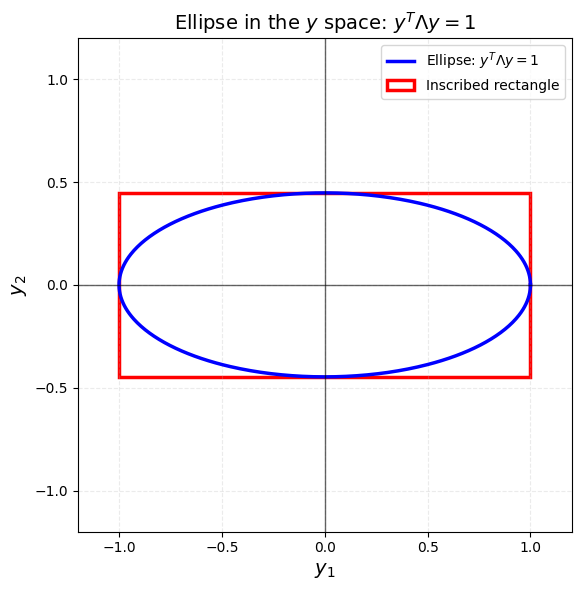

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

# ==================================================
# Matrix and spectral decomposition
# ==================================================

A = np.array([[3, 2], [2, 3]])

eigvals, Q = np.linalg.eigh(A)
Lambda = np.diag(eigvals)

# ==================================================
# Ellipse in y-space: y^T Λ y = 1
# ==================================================

a_y = 1 / np.sqrt(eigvals[0])
b_y = 1 / np.sqrt(eigvals[1])

theta = np.linspace(0, 2*np.pi, 600)

y1 = a_y * np.cos(theta)
y2 = b_y * np.sin(theta)

# ==================================================
# Figure (clean thesis style)
# ==================================================

fig, ax = plt.subplots(figsize=(7, 6))

# Ellipse
ax.plot(
    y1, y2,
    linewidth=2.5,
    color='blue',
    label=r'Ellipse: $y^T \Lambda y = 1$'
)

# Rectangle (only geometry, no vertices)
rect = Rectangle(
    (-a_y, -b_y),
    2*a_y,
    2*b_y,
    edgecolor='red',
    facecolor='none',
    linewidth=2.5,
    label='Inscribed rectangle'
)

ax.add_patch(rect)

# Axes (light style like thesis figure)
ax.axhline(0, color='black', linewidth=1, alpha=0.6)
ax.axvline(0, color='black', linewidth=1, alpha=0.6)

# Labels
ax.set_xlabel(r'$y_1$', fontsize=14)
ax.set_ylabel(r'$y_2$', fontsize=14)

# Limits
ax.set_xlim(-1.2, 1.2)
ax.set_ylim(-1.2, 1.2)

# Aspect ratio
ax.set_aspect('equal')

# Grid (light)
ax.grid(True, linestyle='--', alpha=0.25)

# Legend
ax.legend(loc='upper right')

# Title (optional for thesis you can remove)
ax.set_title(r'Ellipse in the $y$ space: $y^T \Lambda y = 1$', fontsize=14)

plt.tight_layout()

# ==================================================
# Save figure for LaTeX
# ==================================================

plt.savefig("ellipse_y_space.png", dpi=300, bbox_inches='tight')

plt.show()

next figure

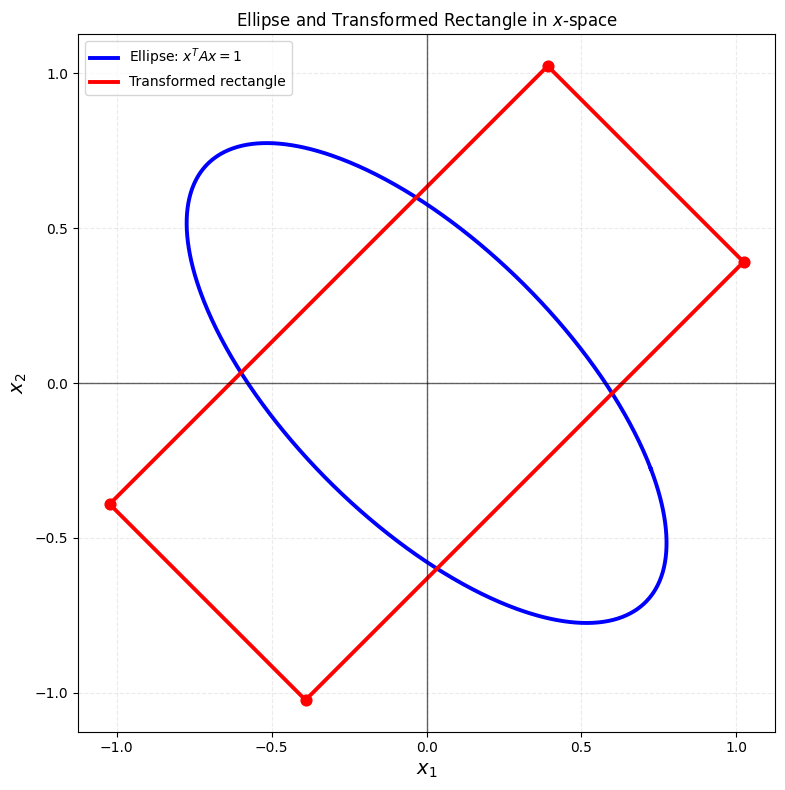


Vertices in x-space:

V1: [-1.02333455 -0.39087902]  |  x^T A x = 5.20000000
V2: [-0.39087902 -1.02333455]  |  x^T A x = 5.20000000
V3: [1.02333455 0.39087902]  |  x^T A x = 5.20000000
V4: [0.39087902 1.02333455]  |  x^T A x = 5.20000000


In [16]:
import numpy as np
import matplotlib.pyplot as plt

# ==================================================
# Matrix and spectral decomposition
# ==================================================

A = np.array([[3, 2], [2, 3]])
eigvals, Q = np.linalg.eigh(A)

# ==================================================
# Ellipse in x-space: x^T A x = 1
# ==================================================

theta = np.linspace(0, 2*np.pi, 800)
circle = np.vstack([np.cos(theta), np.sin(theta)])

A_inv_sqrt = Q @ np.diag(1/np.sqrt(eigvals)) @ Q.T
ellipse = A_inv_sqrt @ circle

# ==================================================
# Rectangle in y-space (your definition)
# ==================================================

a_y = 1/np.sqrt(5)
b_y = 1

vertices_y = np.array([
    [ a_y,  b_y],
    [ a_y, -b_y],
    [-a_y, -b_y],
    [-a_y,  b_y]
])

# ==================================================
# Transform to x-space
# ==================================================

vertices_x = (Q @ vertices_y.T).T

# Correct ordering (counterclockwise geometric order)
center = np.mean(vertices_x, axis=0)
angles = np.arctan2(vertices_x[:,1] - center[1],
                    vertices_x[:,0] - center[0])

vertices_x = vertices_x[np.argsort(angles)]
vertices_x = np.vstack([vertices_x, vertices_x[0]])

# ==================================================
# Plot (clean thesis style)
# ==================================================

fig, ax = plt.subplots(figsize=(8, 8))

# Ellipse
ax.plot(
    ellipse[0], ellipse[1],
    linewidth=2.8,
    color='blue',
    label=r'Ellipse: $x^T A x = 1$'
)

# Rectangle
ax.plot(
    vertices_x[:,0], vertices_x[:,1],
    linewidth=2.8,
    color='red',
    label='Transformed rectangle'
)

# Vertices (kept minimal, no labels clutter)
ax.scatter(vertices_x[:-1,0], vertices_x[:-1,1],
            color='red', s=60)

# Axes
ax.axhline(0, color='black', linewidth=1, alpha=0.6)
ax.axvline(0, color='black', linewidth=1, alpha=0.6)

ax.set_xlabel(r'$x_1$', fontsize=14)
ax.set_ylabel(r'$x_2$', fontsize=14)

ax.set_aspect('equal')
ax.grid(True, linestyle='--', alpha=0.25)

ax.legend()
ax.set_title(r'Ellipse and Transformed Rectangle in $x$-space')

plt.tight_layout()
plt.show()

# ==================================================
# Verification
# ==================================================

print("\nVertices in x-space:\n")
for i, v in enumerate(vertices_x[:-1]):
    print(f"V{i+1}: {v}  |  x^T A x = {v @ A @ v:.8f}")